In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('../data/raw.csv', index_col=0)

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (150000, 11)

Column names:
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

First 5 rows:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

## 2. Target Variable Analysis

Before analysing any features, we first examine our target variable 
`SeriousDlqin2yrs` — whether a borrower defaulted within 2 years.
This tells us the baseline default rate and whether we have a 
class imbalance problem.

Target distribution:
  Non-default (0): 139,974 (93.3%)
  Default     (1): 10,026 (6.7%)


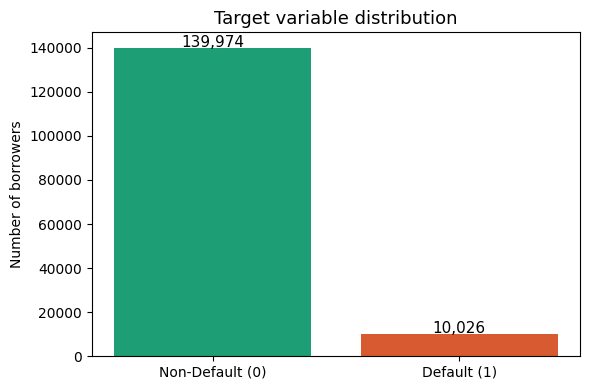

Chart saved to reports folder


In [ ]:
# How many defaulters vs non-defaulters?
target_counts = df['SeriousDlqin2yrs'].value_counts()
target_pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

print("Target distribution:")
print(f"  Non-default (0): {target_counts[0]:,} ({target_pct[0]:.1f}%)")
print(f"  Default     (1): {target_counts[1]:,} ({target_pct[1]:.1f}%)")

# Plot it
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Non-Default (0)', 'Default (1)'], 
       target_counts.values,
       color=['#1D9E75', '#D85A30'])
ax.set_title('Target variable distribution', fontsize=13)
ax.set_ylabel('Number of borrowers')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/01_target_distribution.png', dpi=150)
plt.show()
print("Chart saved to reports folder")

### Finding 1 — Class Imbalance

- Non-default (0): ~93.3% of borrowers
- Default (1): ~6.7% of borrowers

The dataset is significantly imbalanced. This is realistic for a 
subprime US lending portfolio during the 2008 financial crisis period.

**Implication:** Accuracy is a misleading metric here. A naive model 
predicting "no default" for everyone would be 93% accurate but useless.
We will use KS Statistic, Gini, and AUC-ROC as primary validation metrics,
and address imbalance during model training via class_weight parameter
in logistic regression.

## 3. Distribution Analysis & Outlier Detection

We plot the distribution of each variable to:
- Understand the shape and spread of each variable
- Identify extreme outliers that could distort the model
- Spot any impossible or sentinel values in the data

We compare the 99th percentile vs the maximum value for each variable —
a large gap between these two numbers signals a data quality problem.

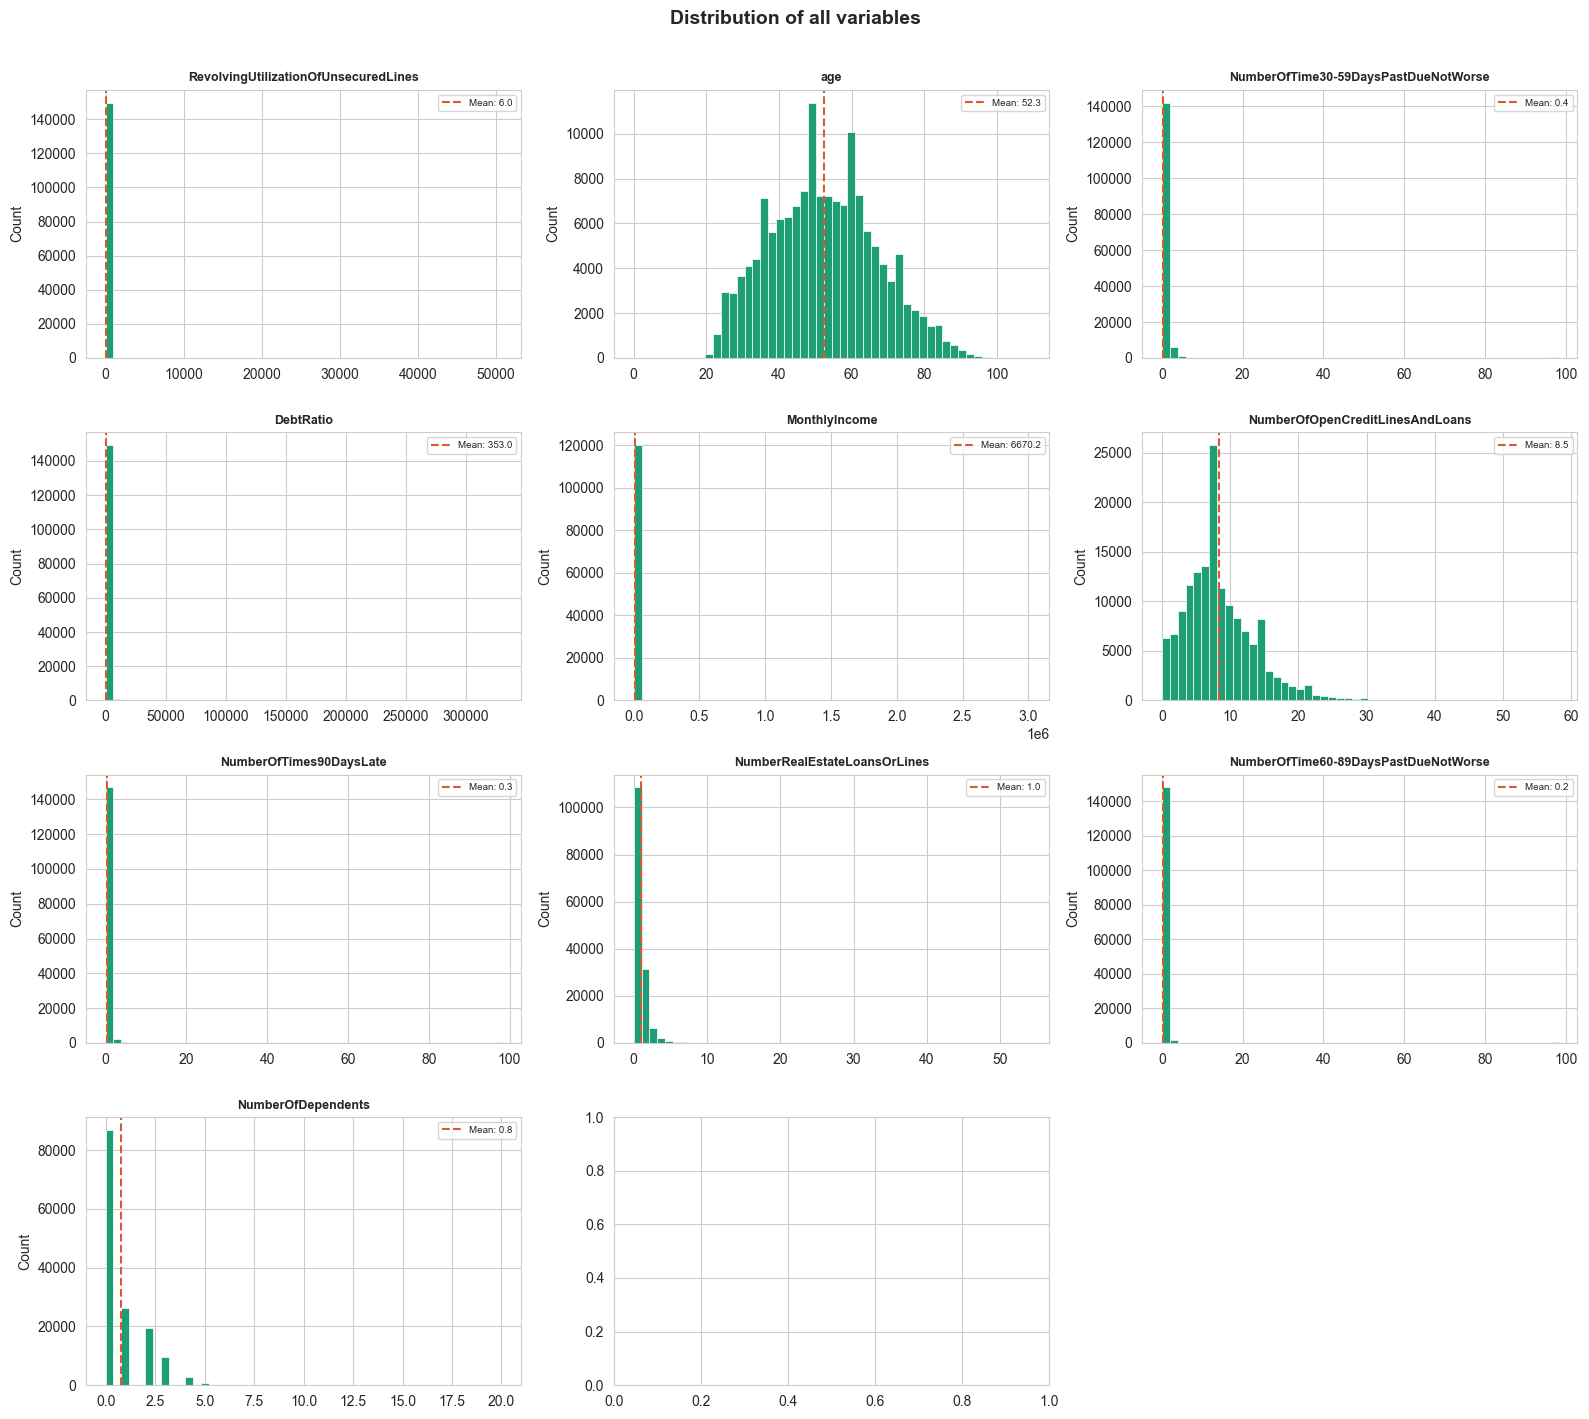

Chart saved to reports folder


In [ ]:
# Set a clean style for all charts
sns.set_style("whitegrid")
sns.set_palette("husl")

# List all feature columns (everything except the target)
features = [col for col in df.columns if col != 'SeriousDlqin2yrs']

# Plot distribution of each variable
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col].dropna(), bins=50, color='#1D9E75', 
                 edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    # Add mean line
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='#D85A30', 
                    linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=7)

# Hide the empty 12th subplot
axes[11].set_visible(False)

plt.suptitle('Distribution of all variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/02_variable_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports folder")

In [7]:
# First let's see how bad the outliers actually are
print("=== Outlier Check — 99th Percentile vs Maximum ===\n")
for col in features:
    p99 = df[col].quantile(0.99)
    p1  = df[col].quantile(0.01)
    max_val = df[col].max()
    min_val = df[col].min()
    print(f"{col[:45]:<45} | 1st%: {p1:>10.1f} | 99th%: {p99:>10.1f} | Max: {max_val:>12.1f}")

=== Outlier Check — 99th Percentile vs Maximum ===

RevolvingUtilizationOfUnsecuredLines          | 1st%:        0.0 | 99th%:        1.1 | Max:      50708.0
age                                           | 1st%:       24.0 | 99th%:       87.0 | Max:        109.0
NumberOfTime30-59DaysPastDueNotWorse          | 1st%:        0.0 | 99th%:        4.0 | Max:         98.0
DebtRatio                                     | 1st%:        0.0 | 99th%:     4979.0 | Max:     329664.0
MonthlyIncome                                 | 1st%:        0.0 | 99th%:    25000.0 | Max:    3008750.0
NumberOfOpenCreditLinesAndLoans               | 1st%:        0.0 | 99th%:       24.0 | Max:         58.0
NumberOfTimes90DaysLate                       | 1st%:        0.0 | 99th%:        3.0 | Max:         98.0
NumberRealEstateLoansOrLines                  | 1st%:        0.0 | 99th%:        4.0 | Max:         54.0
NumberOfTime60-89DaysPastDueNotWorse          | 1st%:        0.0 | 99th%:        2.0 | Max:         98.0
Num

### Finding 2 — Severe Outliers Detected

The 99th percentile vs maximum comparison reveals serious data quality issues:

| Variable | 99th Percentile | Maximum | Issue |
|---|---|---|---|
| RevolvingUtilization | 1.1 | 50,708 | Impossible — it is a ratio, max should be 1.0 |
| DebtRatio | 4,979 | 329,664 | Clearly erroneous — debt 300,000x income |
| MonthlyIncome | 25,000 | 3,008,750 | Extreme outlier — $36M annual income |
| NumberOfTimes90DaysLate | 3 | 98 | Sentinel value — 96/97/98 are system codes |
| NumberOfTime30-59DaysPastDue | 4 | 98 | Sentinel value — same issue |
| NumberOfTime60-89DaysPastDue | 2 | 98 | Sentinel value — same issue |

**Key insight on sentinel values:** In banking systems, values like 96, 97, 98 
in count fields are often system-generated codes meaning "data unavailable" 
or "error" — not actual delinquency counts. This is a common real-world 
data quality issue in bank model development.

## 4. Data Cleaning & Treatment

Based on the findings above, we apply three types of treatment:

**Treatment 1 — Sentinel values**
Replace 96/97/98 in delinquency columns with NaN, then impute with 0.
Rationale: no record of delinquency is best interpreted as no delinquency.

**Treatment 2 — Outlier capping (Winsorization)**
Cap extreme values at the 99th percentile.
Rationale: values beyond the 99th percentile are almost certainly data 
errors. We cap rather than delete to preserve the row's other information.
RevolvingUtilization is hard-capped at 1.0 — it is a ratio by definition.

**Treatment 3 — Missing value imputation**
- MonthlyIncome (~20% missing): impute with median
- NumberOfDependents (~2.6% missing): impute with median
- Median chosen over mean because both variables are right-skewed —
  the mean would be pulled upward by remaining high values, 
  giving an unrepresentative imputation value.

**Treatment 4 — Invalid ages**
Drop rows where age = 0. These are data entry errors — 
no borrower can be 0 years old.

In [ ]:
# ============================================================
# Data Cleaning & Outlier Treatment
# ============================================================

df_clean = df.copy()  # Always work on a copy, never destroy raw data

# ------------------------------------------------------------
# 1. Fix sentinel values in delinquency columns
#    96, 97, 98 are system codes — treat as missing (NaN)
# ------------------------------------------------------------
delinquency_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate', 
    'NumberOfTime60-89DaysPastDueNotWorse'
]

for col in delinquency_cols:
    mask = df_clean[col] >= 90  # 96, 97, 98 are the sentinel values
    print(f"{col}: {mask.sum()} sentinel values replaced with NaN")
    df_clean.loc[mask, col] = np.nan

# ------------------------------------------------------------
# 2. Cap outliers at 99th percentile (Winsorization)
#    For variables where extreme values are data errors
# ------------------------------------------------------------
cap_cols = {
    'RevolvingUtilizationOfUnsecuredLines': (0, 1),  # It's a ratio — hard cap at 1
    'DebtRatio':          (None, df_clean['DebtRatio'].quantile(0.99)),
    'MonthlyIncome':      (None, df_clean['MonthlyIncome'].quantile(0.99)),
    'NumberOfDependents': (None, df_clean['NumberOfDependents'].quantile(0.99)),
}

for col, (lower, upper) in cap_cols.items():
    before = df_clean[col].max()
    if upper: df_clean[col] = df_clean[col].clip(upper=upper)
    if lower is not None: df_clean[col] = df_clean[col].clip(lower=lower)
    after = df_clean[col].max()
    print(f"{col[:45]:<45} | Before max: {before:>12.1f} | After max: {after:>10.1f}")

# ------------------------------------------------------------
# 3. Handle missing values
#    MonthlyIncome  — impute with median (20% missing, too much to drop)
#    NumberOfDependents — impute with median (2.6% missing)
#    Delinquency cols  — impute with 0 (no record = no delinquency)
# ------------------------------------------------------------
print("\n=== Missing Value Treatment ===")

# Median imputation for income
median_income = df_clean['MonthlyIncome'].median()
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(median_income)
print(f"MonthlyIncome: filled {df['MonthlyIncome'].isna().sum()} missing with median: ${median_income:,.0f}")

# Median imputation for dependents
median_dep = df_clean['NumberOfDependents'].median()
df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(median_dep)
print(f"NumberOfDependents: filled {df['NumberOfDependents'].isna().sum()} missing with median: {median_dep}")

# Zero imputation for delinquency (NaN means no record of delinquency)
for col in delinquency_cols:
    missing = df_clean[col].isna().sum()
    df_clean[col] = df_clean[col].fillna(0)
    print(f"{col[:45]}: filled {missing} missing with 0")

# ------------------------------------------------------------
# 4. Fix age — anyone aged 0 is clearly an error, drop those rows
# ------------------------------------------------------------
age_errors = (df_clean['age'] == 0).sum()
df_clean = df_clean[df_clean['age'] > 0]
print(f"\nDropped {age_errors} rows with age = 0")

# ------------------------------------------------------------
# 5. Final check
# ------------------------------------------------------------
print(f"\n=== Final Dataset ===")
print(f"Shape: {df_clean.shape}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

NumberOfTime30-59DaysPastDueNotWorse: 269 sentinel values replaced with NaN
NumberOfTimes90DaysLate: 269 sentinel values replaced with NaN
NumberOfTime60-89DaysPastDueNotWorse: 269 sentinel values replaced with NaN
RevolvingUtilizationOfUnsecuredLines          | Before max:      50708.0 | After max:        1.0
DebtRatio                                     | Before max:     329664.0 | After max:     4979.0
MonthlyIncome                                 | Before max:    3008750.0 | After max:    25000.0
NumberOfDependents                            | Before max:         20.0 | After max:        4.0

=== Missing Value Treatment ===
MonthlyIncome: filled 29731 missing with median: $5,400
NumberOfDependents: filled 3924 missing with median: 0.0
NumberOfTime30-59DaysPastDueNotWorse: filled 269 missing with 0
NumberOfTimes90DaysLate: filled 269 missing with 0
NumberOfTime60-89DaysPastDueNotWorse: filled 269 missing with 0

Dropped 1 rows with age = 0

=== Final Dataset ===
Shape: (149999, 11)


### Finding 3 — Data Quality Summary After Cleaning

- Sentinel values in delinquency columns: replaced and imputed
- RevolvingUtilization: capped at 1.0 (hard business rule)
- DebtRatio, MonthlyIncome, NumberOfDependents: capped at 99th percentile
- MonthlyIncome missing values: imputed with median
- NumberOfDependents missing values: imputed with median  
- Age = 0 rows: dropped
- Zero missing values remaining in cleaned dataset

Cleaned dataset saved to data/cleaned.csv for use in subsequent notebooks.

## 5. Variable Distributions — After Cleaning

We now re-examine all variable distributions on the cleaned dataset.
Outlier capping has removed the extreme values that were distorting 
the charts, giving us a true picture of each variable's distribution.

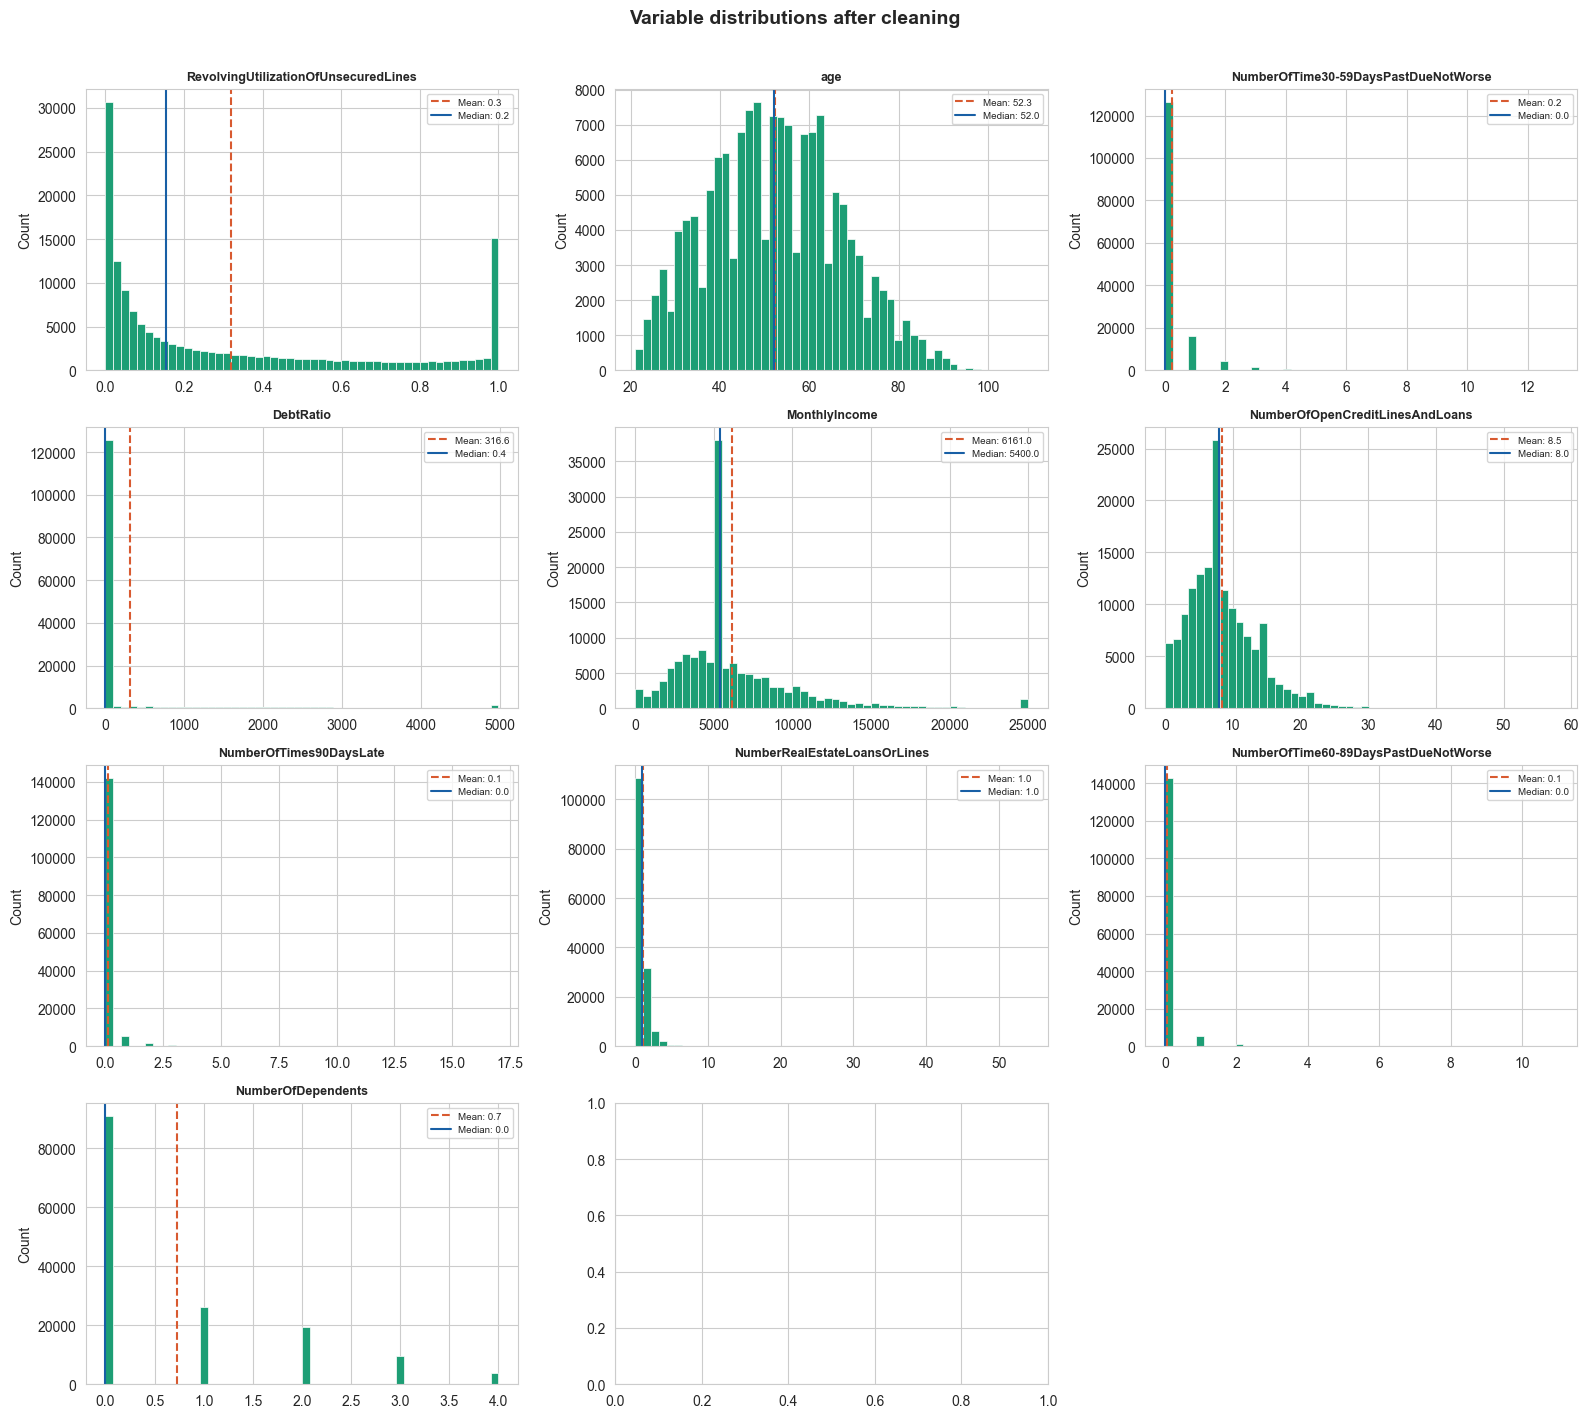

Chart saved to reports folder


In [ ]:
# ============================================================
# Clean Distribution Charts (post cleaning)
# ============================================================

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df_clean[col].dropna(), bins=50, 
                 color='#1D9E75', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Count')
    
    mean_val = df_clean[col].mean()
    median_val = df_clean[col].median()
    
    axes[i].axvline(mean_val, color='#D85A30', linestyle='--', 
                    linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='#185FA5', linestyle='-', 
                    linewidth=1.5, label=f'Median: {median_val:.1f}')
    axes[i].legend(fontsize=7)

# Hide empty 12th subplot
axes[11].set_visible(False)

plt.suptitle('Variable distributions after cleaning', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/03_clean_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports folder")

### Finding 4 — Distribution Insights After Cleaning

**Age** — only normally distributed variable. Well-behaved, no issues.

**Delinquency variables** (30-59, 60-89, 90+ days late) — zero-inflated
distributions. The vast majority of borrowers have never been late.
These will need special treatment during WoE binning.

**DebtRatio** — still skewed after capping. Mean (316) vs Median (0.4)
gap is very large — driven by genuinely high-debt borrowers even after
removing extreme outliers.

**MonthlyIncome** — artificial spike at $5,400 is a median imputation 
artefact. 29,731 missing values were all filled with the same median value,
creating an unnaturally tall bar. Limitation to note in model documentation.

**RevolvingUtilization** — spike at 1.0 is a capping artefact. All values
above 1.0 were brought down to exactly 1.0, creating a concentration at
the cap boundary. Hard cap is correct since utilization is a ratio.

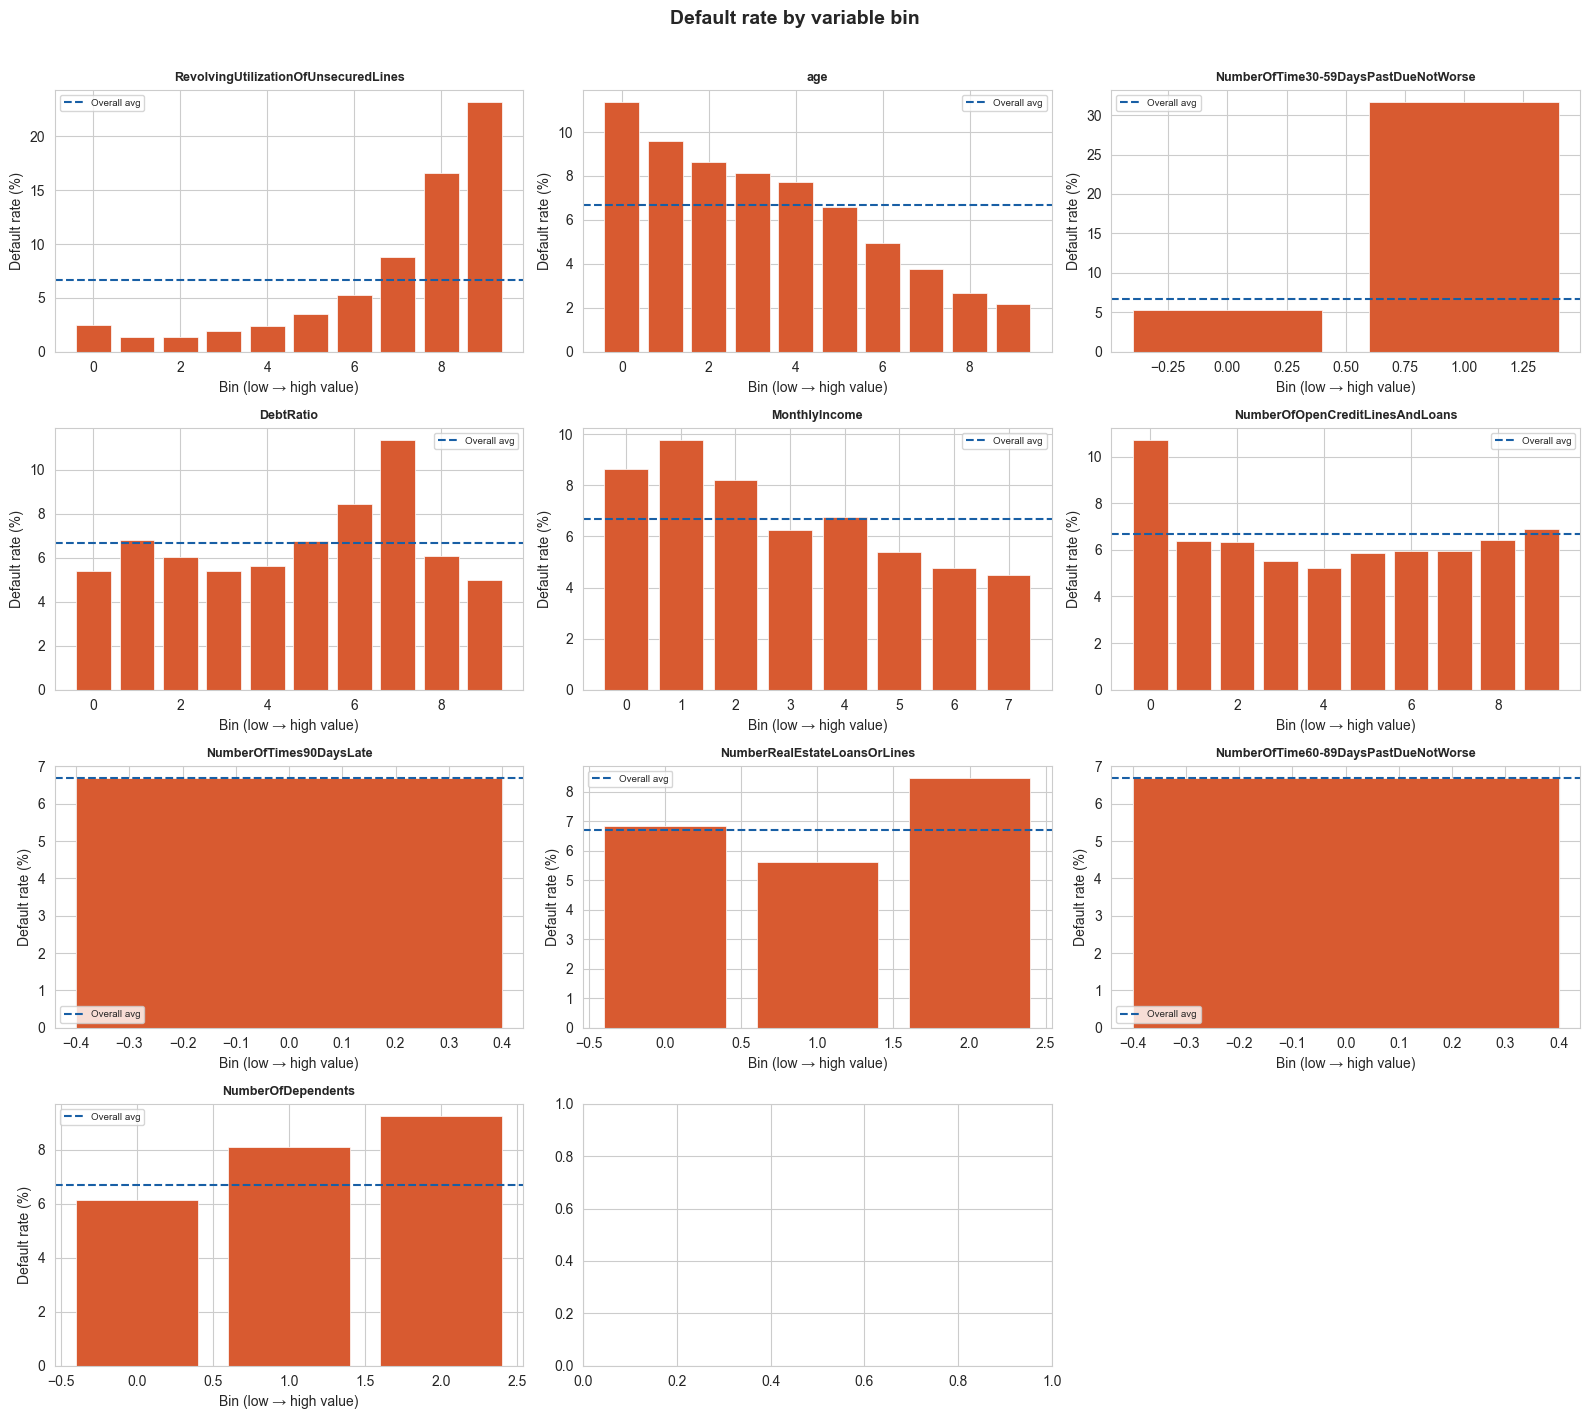

Chart saved to reports folder


In [ ]:
# ============================================================
# Default Rate by Variable (binned)
# ============================================================

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    # Create 10 equal-sized bins for each variable
    try:
        df_clean['temp_bin'] = pd.qcut(df_clean[col], q=10, 
                                        duplicates='drop')
        default_rate = df_clean.groupby('temp_bin', observed=True)['SeriousDlqin2yrs'].mean() * 100
        
        axes[i].bar(range(len(default_rate)), default_rate.values, 
                   color='#D85A30', edgecolor='white', linewidth=0.5)
        axes[i].set_title(col, fontsize=9, fontweight='bold')
        axes[i].set_ylabel('Default rate (%)')
        axes[i].set_xlabel('Bin (low → high value)')
        axes[i].axhline(y=df_clean['SeriousDlqin2yrs'].mean()*100, 
                       color='#185FA5', linestyle='--', 
                       linewidth=1.5, label='Overall avg')
        axes[i].legend(fontsize=7)
    except Exception as e:
        axes[i].set_title(f"{col}\n(cannot bin)", fontsize=9)

df_clean.drop(columns=['temp_bin'], inplace=True)

axes[11].set_visible(False)

plt.suptitle('Default rate by variable bin', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/04_default_rate_by_variable.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports folder")

### Finding 5 — Predictive Power Assessment (Pre-WoE)

Based on default rate analysis across bins, variables are ranked as:

**Strong predictors (clear monotonic trend):**
- RevolvingUtilizationOfUnsecuredLines — default rate rises from 2% to 23%
- age — default rate falls from 11% to 2% (younger = riskier)
- NumberOfTime30-59DaysPastDueNotWorse — default rate jumps to 30%+ 
  at high delinquency. Strongest visual signal in the dataset.

**Moderate predictors:**
- MonthlyIncome — lower income correlates with higher default rate

**Weak predictors (flat or unclear trend):**
- DebtRatio — surprisingly weak. No clear monotonic relationship.
- NumberOfOpenCreditLinesAndLoans — flat across bins
- NumberRealEstateLoansOrLines — insufficient variation
- NumberOfDependents — very weak signal

**Zero-inflated variables (binning broke down — needs WoE treatment):**
- NumberOfTimes90DaysLate
- NumberOfTime60-89DaysPastDueNotWorse

Note: These visual assessments will be confirmed mathematically using Information Value (IV). 
IV provides an objective, quantitative measure of each variable's predictive power.

In [ ]:
# ============================================================
# Save cleaned dataset
# ============================================================

df_clean.to_csv('../data/cleaned.csv')
print(f"Cleaned dataset saved.")
print(f"Shape: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"\nSaved to: data/cleaned.csv")

Cleaned dataset saved.
Shape: (149999, 11)
Missing values: 0

Saved to: data/cleaned.csv
